<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Pop_Pyramid_Clustering/blob/main/PopStats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reduced dimensions to: 6


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Optimal clusters based on Silhouette Score: 3


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


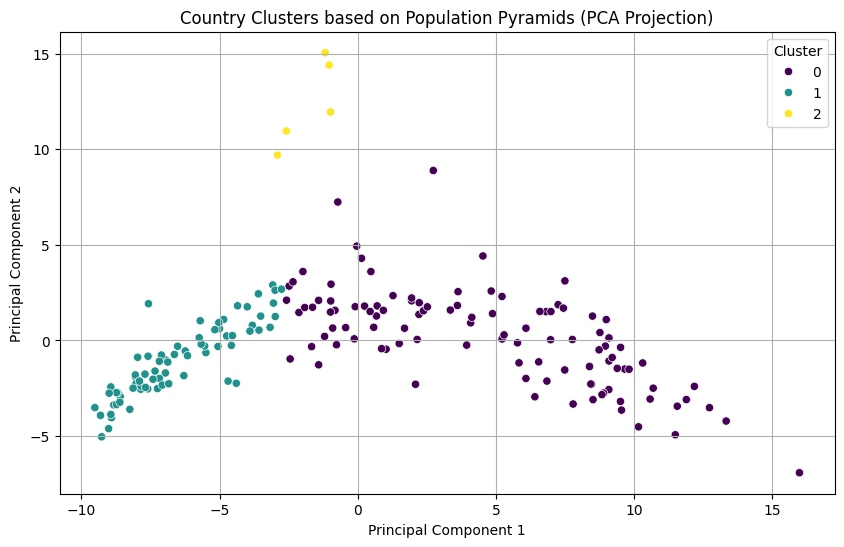

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

# 1. Load Data
df = pd.read_csv('age_data_1.csv')

# Filter for the year 2020
df_2020 = df[df['Time'] == 2020].copy()

# 2. Feature Engineering for Population Pyramids
# Identify columns representing population counts
population_value_cols = ['PopMale', 'PopFemale', 'PopTotal'] # Assuming these are the population count columns

# Ensure these columns are numeric, coercing errors and filling NaNs with 0
for col in population_value_cols:
    if col in df_2020.columns: # Check if column exists
        df_2020[col] = pd.to_numeric(df_2020[col], errors='coerce').fillna(0)

# Reshape the data for country-level clustering.
# Each row should be a country, and columns should be population counts per age group and gender.
# First, melt the population columns to long format
df_long = df_2020.melt(
    id_vars=['Location', 'Time', 'AgeGrp'],
    value_vars=population_value_cols,
    var_name='PopulationType', # e.g., 'PopMale', 'PopFemale'
    value_name='PopulationValue'
)

# Create a combined 'Feature' column (e.g., 'PopMale_0-4', 'PopFemale_5-9')
df_long['Feature'] = df_long['PopulationType'] + '_' + df_long['AgeGrp']

# Pivot the table to get countries as rows and features as columns
X_pivoted = df_long.pivot_table(
    index='Location',
    columns='Feature',
    values='PopulationValue',
    aggfunc='sum' # Aggregate in case of multiple entries (should ideally be unique per Location-AgeGrp-PopulationType)
)

# Fill any NaNs that might arise from pivoting (e.g., if a country is missing an age group entirely)
X = X_pivoted.fillna(0)

# Ensure all columns in X are numeric after pivoting (should be from previous steps, but safe check)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 3. Normalization (Percentage of total population for each country)
# Sum across columns for each country to get its total population represented in X
total_population_per_country = X.sum(axis=1)

# Replace 0 sums with 1 to avoid division by zero errors; countries with 0 total pop will have 0% for all features
total_population_per_country[total_population_per_country == 0] = 1

X_pct = X.div(total_population_per_country, axis=0)

# 4. Standardizing for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct)

# 5. Dimensionality Reduction (PCA)
pca = PCA(n_components=0.95) # Keep 95% of variance
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced dimensions to: {X_pca.shape[1]}")

# 6. Finding Optimal Clusters (Silhouette Method)
# We test a range to find the best 'k'
scores = []
k_range = range(2, 8)
for k in k_range:
    # Using 'nearest_neighbors' for affinity requires n_neighbors <= n_samples
    # Ensure n_neighbors is not greater than the number of samples (countries)
    n_neighbors_val = min(k + 1, X_pca.shape[0] -1 ) # Ensure n_neighbors is at least 1 and less than n_samples
    if n_neighbors_val < 2: # SpectralClustering requires n_neighbors >= 2
        n_neighbors_val = 2

    sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_neighbors=n_neighbors_val, random_state=42)
    labels = sc.fit_predict(X_pca)
    # Silhouette score requires at least 2 clusters and more than 1 sample per cluster for meaningful score
    if len(np.unique(labels)) > 1:
        scores.append(silhouette_score(X_pca, labels))
    else:
        scores.append(-1) # Assign a low score if only one cluster found or issue prevents score

# If all scores are -1 (meaning no valid silhouette scores were computed), handle this case
if max(scores) == -1:
    optimal_k = k_range[0] # Default to the smallest k if no valid scores
    print("Warning: Could not compute valid silhouette scores for most k values. Defaulting to smallest k.")
elif len(scores) > 0:
    optimal_k = k_range[np.argmax(scores)]
else:
    optimal_k = 2 # Default to 2 if no scores were appended at all

print(f"Optimal clusters based on Silhouette Score: {optimal_k}")

# 7. Final Clustering
# Ensure n_neighbors is valid for the final model as well
n_neighbors_val_final = min(optimal_k + 1, X_pca.shape[0] -1)
if n_neighbors_val_final < 2:
    n_neighbors_val_final = 2

model = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', n_neighbors=n_neighbors_val_final, random_state=42)
cluster_labels = model.fit_predict(X_pca)

# Add cluster labels back to the pivoted DataFrame (X_pct or X, as they have 'Location' as index)
X['Cluster'] = cluster_labels

# 8. Visualization of PCA Components
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=X['Cluster'], palette='viridis')
plt.title('Country Clusters based on Population Pyramids (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

Reduced dimensions to: 6
Optimal clusters based on Silhouette Score: 3


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


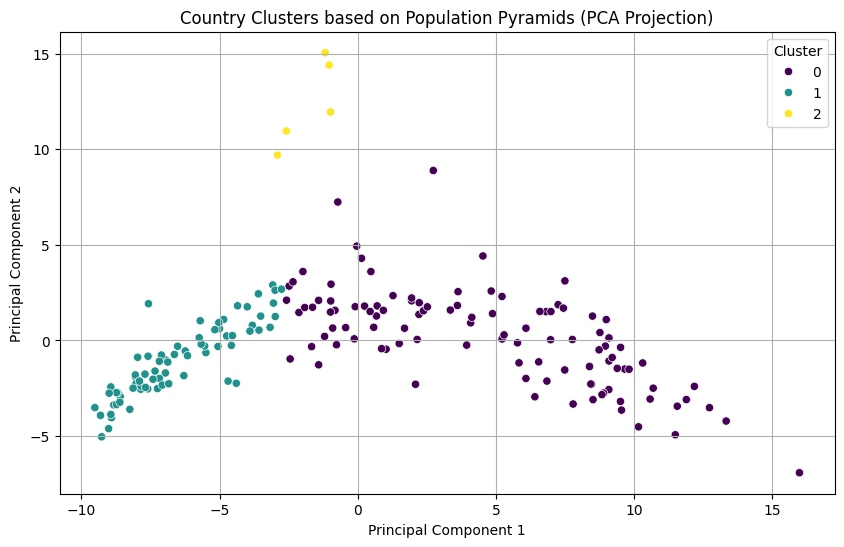

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

# 1. Load Data
df = pd.read_csv('age_data_1.csv', on_bad_lines='skip')

# Filter for the year 2020
df_2020 = df[df['Time'] == 2020].copy()

# 2. Feature Engineering for Population Pyramids
# Identify columns representing population counts
population_value_cols = ['PopMale', 'PopFemale', 'PopTotal'] # Assuming these are the population count columns

# Ensure these columns are numeric, coercing errors and filling NaNs with 0
for col in population_value_cols:
    if col in df_2020.columns: # Check if column exists
        df_2020[col] = pd.to_numeric(df_2020[col], errors='coerce').fillna(0)

# Reshape the data for country-level clustering.
# Each row should be a country, and columns should be population counts per age group and gender.
# First, melt the population columns to long format
df_long = df_2020.melt(
    id_vars=['Location', 'Time', 'AgeGrp'],
    value_vars=population_value_cols,
    var_name='PopulationType', # e.g., 'PopMale', 'PopFemale'
    value_name='PopulationValue'
)

# Create a combined 'Feature' column (e.g., 'PopMale_0-4', 'PopFemale_5-9')
df_long['Feature'] = df_long['PopulationType'] + '_' + df_long['AgeGrp']

# Pivot the table to get countries as rows and features as columns
X_pivoted = df_long.pivot_table(
    index='Location',
    columns='Feature',
    values='PopulationValue',
    aggfunc='sum' # Aggregate in case of multiple entries (should ideally be unique per Location-AgeGrp-PopulationType)
)

# Fill any NaNs that might arise from pivoting (e.g., if a country is missing an age group entirely)
X = X_pivoted.fillna(0)

# Ensure all columns in X are numeric after pivoting (should be from previous steps, but safe check)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 3. Normalization (Percentage of total population for each country)
# Sum across columns for each country to get its total population represented in X
total_population_per_country = X.sum(axis=1)

# Replace 0 sums with 1 to avoid division by zero errors; countries with 0 total pop will have 0% for all features
total_population_per_country[total_population_per_country == 0] = 1

X_pct = X.div(total_population_per_country, axis=0)

# 4. Standardizing for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct)

# 5. Dimensionality Reduction (PCA)
pca = PCA(n_components=0.95) # Keep 95% of variance
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced dimensions to: {X_pca.shape[1]}")

# 6. Finding Optimal Clusters (Silhouette Method)
# We test a range to find the best 'k'
scores = []
k_range = range(2, 8)
for k in k_range:
    # Using 'nearest_neighbors' for affinity requires n_neighbors <= n_samples
    # Ensure n_neighbors is not greater than the number of samples (countries)
    n_neighbors_val = min(k + 1, X_pca.shape[0] -1 ) # Ensure n_neighbors is at least 1 and less than n_samples
    if n_neighbors_val < 2: # SpectralClustering requires n_neighbors >= 2
        n_neighbors_val = 2

    sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_neighbors=n_neighbors_val, random_state=42)
    labels = sc.fit_predict(X_pca)
    # Silhouette score requires at least 2 clusters and more than 1 sample per cluster for meaningful score
    if len(np.unique(labels)) > 1:
        scores.append(silhouette_score(X_pca, labels))
    else:
        scores.append(-1) # Assign a low score if only one cluster found or issue prevents score

# If all scores are -1 (meaning no valid silhouette scores were computed), handle this case
if max(scores) == -1:
    optimal_k = k_range[0] # Default to the smallest k if no valid scores
    print("Warning: Could not compute valid silhouette scores for most k values. Defaulting to smallest k.")
elif len(scores) > 0:
    optimal_k = k_range[np.argmax(scores)]
else:
    optimal_k = 2 # Default to 2 if no scores were appended at all

print(f"Optimal clusters based on Silhouette Score: {optimal_k}")

# 7. Final Clustering
# Ensure n_neighbors is valid for the final model as well
n_neighbors_val_final = min(optimal_k + 1, X_pca.shape[0] -1)
if n_neighbors_val_final < 2:
    n_neighbors_val_final = 2

model = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', n_neighbors=n_neighbors_val_final, random_state=42)
cluster_labels = model.fit_predict(X_pca)

# Add cluster labels back to the pivoted DataFrame (X_pct or X, as they have 'Location' as index)
X['Cluster'] = cluster_labels

# 8. Visualization of PCA Components
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=X['Cluster'], palette='viridis')
plt.title('Country Clusters based on Population Pyramids (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:
# 9. Print Country Lists for each Cluster
print("\n" + "="*50)
print("COUNTRY LISTS BY CLUSTER")
print("="*50)

# Define descriptive labels based on common demographic trends
# Note: You can swap these if your PCA projection assigns numbers differently
cluster_meanings = {
    0: "High Growth / Expansive (Young Population)",
    1: "Transitional / Bulge (Working-Age Dividend)",
    2: "Aging / Constrictive (Post-Transitional)"
}

for cluster_id in range(optimal_k):
    # Get index (Country names) where cluster matches
    countries = X[X['Cluster'] == cluster_id].index.tolist()

    label = cluster_meanings.get(cluster_id, f"Cluster {cluster_id}")

    print(f"\n--- {label} ---")
    print(f"Total Count: {len(countries)}")
    # Join list into a comma-separated string for readability
    print(", ".join(countries))
    print("-" * 30)

# Optional: Export to CSV
# X[['Cluster']].to_csv('countries_by_cluster.csv')


COUNTRY LISTS BY CLUSTER

--- High Growth / Expansive (Young Population) ---
Total Count: 107
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Australia, Austria, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus, Belgium, Bhutan, Bolivia (Plurinational State of), Bosnia and Herzegovina, Brazil, Brunei Darussalam, Bulgaria, Canada, Chile, China, China, Taiwan Province of China, Colombia, Costa Rica, Croatia, Cuba, Curaçao, Cyprus, Czechia, Dem. People's Republic of Korea, Denmark, Dominican Republic, Ecuador, El Salvador, Estonia, Fiji, Finland, France, Georgia, Germany, Greece, Grenada, Guam, Guyana, Hungary, Iceland, India, Indonesia, Iran (Islamic Republic of), Ireland, Israel, Italy, Jamaica, Japan, Kazakhstan, Kuwait, Latvia, Lebanon, Libya, Lithuania, Luxembourg, Malaysia, Malta, Mauritius, Mexico, Mongolia, Montenegro, Morocco, Myanmar, Netherlands, New Zealand, North Macedonia, Northern Europe, Norway, Panama, Peru, Poland, Portugal, Puerto Rico, Republic of Korea, 

In [ ]:
import plotly.express as px

# 1. Prepare the data for mapping
# Reset index so 'Location' becomes a column, and keep the 'Cluster' column
map_df = X[['Cluster']].reset_index()

# 2. Define Descriptive Labels (based on the demographic logic discussed)
# This makes the map legend much more professional
cluster_labels = {
    0: "Cluster 0: High Growth (Young)",
    1: "Cluster 1: Transitional (Working Age)",
    2: "Cluster 2: Aging (Post-Transitional)"
}
map_df['Demographic Stage'] = map_df['Cluster'].map(cluster_labels)

# 3. Create the Interactive Choropleth Map
fig = px.choropleth(
    map_df,
    locations="Location",          # Column containing country names
    locationmode="country names",  # Use built-in country name matching
    color="Demographic Stage",     # Color countries by cluster description
    hover_name="Location",         # Show name on hover
    title="Global Demographic Clusters 2020 (Spectral Clustering & PCA)",
    # Choose a color palette that shows distinction clearly
    color_discrete_sequence=px.colors.qualitative.Safe
)

# 4. Refine Map Appearance
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth' # A nice, modern-looking world projection
    ),
    legend_title_text='Demographic Cluster',
    margin={"r":0,"t":50,"l":0,"b":0}
)

# 5. Display and/or Save
fig.show()

# If you want to save this as a standalone website/file for a presentation:
# fig.write_html("world_age_clusters_2020.html")

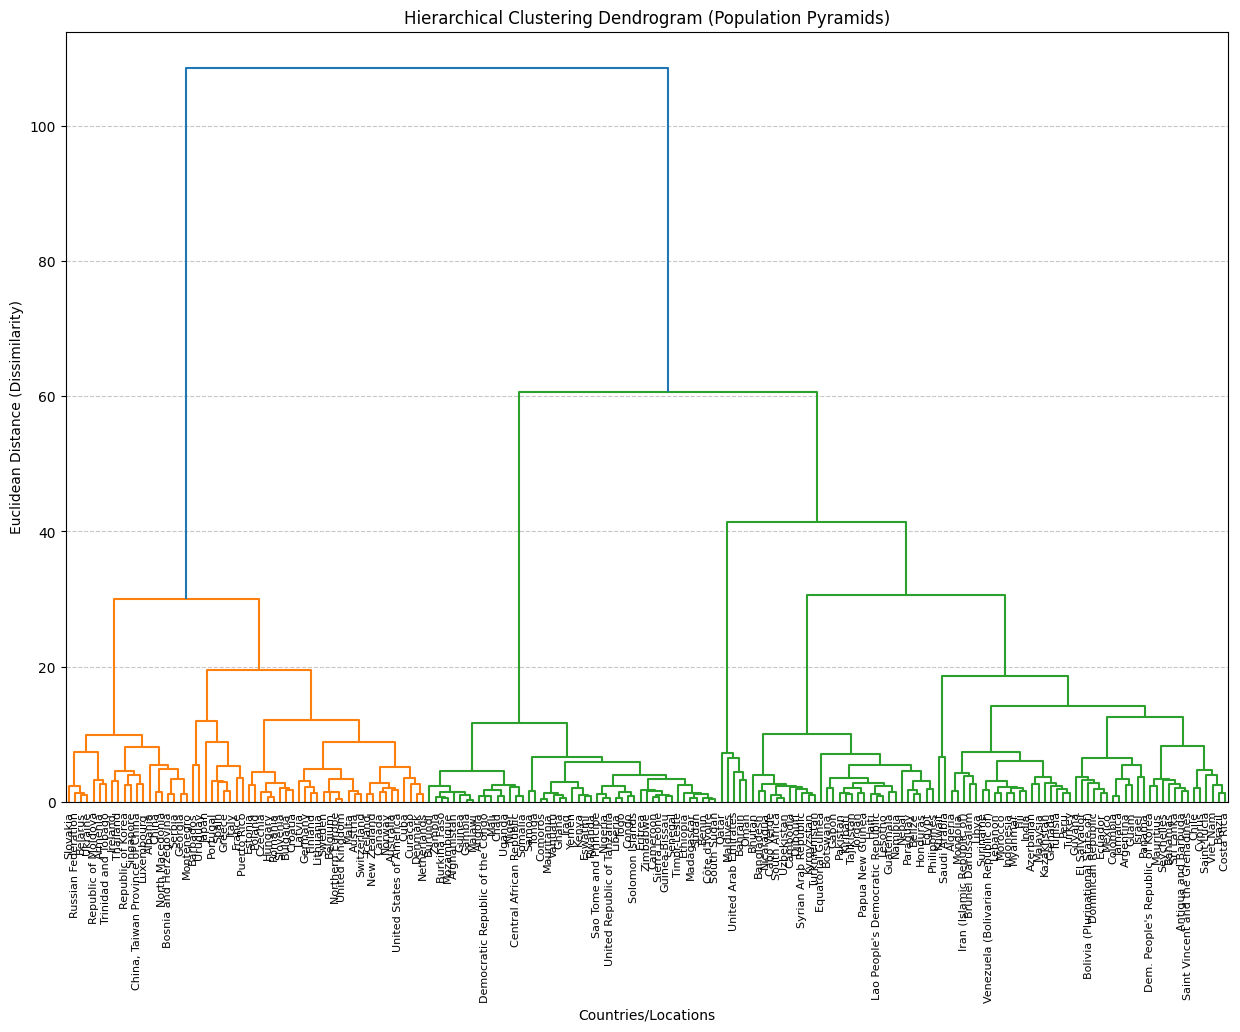


HIERARCHICAL CLUSTERING RESULTS

Cluster 0 - Count: 82
Algeria, Antigua and Barbuda, Argentina, Azerbaijan, Bahamas, Bahrain, Bangladesh, Belize, Bhutan, Bolivia (Plurinational State of), Botswana, Brazil, Brunei Darussalam, Cabo Verde, Cambodia...

Cluster 1 - Count: 58
Albania, Armenia, Australia, Austria, Barbados, Belarus, Belgium, Bosnia and Herzegovina, Bulgaria, Canada, China, China, Taiwan Province of China, Croatia, Cuba, Curaçao...

Cluster 2 - Count: 47
Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Côte d'Ivoire, Democratic Republic of the Congo, Eritrea, Eswatini, Ethiopia...


In [ ]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# 1. Generate the Linkage Matrix
# 'ward' linkage minimizes the variance within clusters (works best with PCA data)
Z = sch.linkage(X_pca, method='ward')

# 2. Plot the Dendrogram
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(
    Z,
    labels=X.index,  # Uses country names from the index
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7 * max(Z[:, 2])
)
plt.title('Hierarchical Clustering Dendrogram (Population Pyramids)')
plt.xlabel('Countries/Locations')
plt.ylabel('Euclidean Distance (Dissimilarity)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Fit Agglomerative Clustering
# We use the same optimal_k found by your silhouette score previously
hc_model = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
X['HC_Cluster'] = hc_model.fit_predict(X_pca)

# 4. Compare and Print the Country Lists
print("\n" + "="*50)
print("HIERARCHICAL CLUSTERING RESULTS")
print("="*50)

for cluster_id in range(optimal_k):
    countries = X[X['HC_Cluster'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id} - Count: {len(countries)}")
    print(", ".join(countries[:15]) + ("..." if len(countries) > 15 else ""))

In [ ]:
from sklearn.metrics import silhouette_score

spectral_score = silhouette_score(X_pca, X['Cluster'])
hierarchical_score = silhouette_score(X_pca, X['HC_Cluster'])

print(f"\nSilhouette Score (Spectral): {spectral_score:.4f}")
print(f"Silhouette Score (Hierarchical): {hierarchical_score:.4f}")


Silhouette Score (Spectral): 0.4632
Silhouette Score (Hierarchical): 0.4130


In [ ]:
import plotly.express as px

# 1. Prepare data for Hierarchical Map
# Reset index to get 'Location' as a column from the X dataframe
map_hc_df = X[['HC_Cluster']].reset_index()

# 2. Assign Descriptive Labels
# Assuming Cluster 0/1/2 follow the demographic stages identified earlier
# (Check your printed country lists to ensure the descriptions match the IDs)
hc_labels = {
    0: "HC Cluster 0: High Growth",
    1: "HC Cluster 1: Transitional",
    2: "HC Cluster 2: Aging"
}
map_hc_df['Demographic Stage (HC)'] = map_hc_df['HC_Cluster'].map(hc_labels)

# 3. Create the Map
fig_hc = px.choropleth(
    map_hc_df,
    locations="Location",
    locationmode="country names",
    color="Demographic Stage (HC)",
    hover_name="Location",
    title="World Map: Hierarchical Clustering of Population Pyramids (2020)",
    color_discrete_sequence=px.colors.qualitative.Bold # Different palette to distinguish from Spectral
)

# 4. Final Layout Adjustments
fig_hc.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig_hc.show()

In [ ]:
import plotly.express as px

def get_cluster_labels(df, cluster_col):
    """
    Automatically assigns demographic labels by checking the
    proportion of young age groups (e.g., PopTotal_0-4).
    """
    # Find a column that represents a young age group to determine the 'Growth' level
    # We use a broad '0-4' or '5-9' filter
    young_cols = [col for col in X_pct.columns if '0-4' in col or '5-9' in col]

    # Calculate the mean 'youth' percentage for each cluster
    youth_means = X_pct.groupby(df[cluster_col])[young_cols].mean().mean(axis=1)

    # Sort clusters by youth percentage: High = High Growth, Low = Aging
    sorted_clusters = youth_means.sort_values(ascending=False).index

    mapping = {
        sorted_clusters[0]: "High Growth (Expansive)",
        sorted_clusters[1]: "Transitional (Stationary)",
        sorted_clusters[2]: "Aging (Constrictive)"
    }
    return mapping

# --- SPECTRAL MAPPING ---
spec_mapping = get_cluster_labels(X, 'Cluster')
X['Spectral_Label'] = X['Cluster'].map(spec_mapping)

# --- HIERARCHICAL MAPPING ---
hier_mapping = get_cluster_labels(X, 'HC_Cluster')
X['Hierarchical_Label'] = X['HC_Cluster'].map(hier_mapping)

# 2. Visualization: Spectral World Map
fig_spec = px.choropleth(
    X.reset_index(),
    locations="Location",
    locationmode="country names",
    color="Spectral_Label",
    title="Spectral Clustering: Demographic Stages 2020",
    color_discrete_map={
        "High Growth (Expansive)": "#EF553B",  # Red
        "Transitional (Stationary)": "#636EFA", # Blue
        "Aging (Constrictive)": "#00CC96"       # Green
    }
)
fig_spec.show()

# 3. Visualization: Hierarchical World Map
fig_hier = px.choropleth(
    X.reset_index(),
    locations="Location",
    locationmode="country names",
    color="Hierarchical_Label",
    title="Hierarchical Clustering: Demographic Stages 2020",
    color_discrete_map={
        "High Growth (Expansive)": "#EF553B",
        "Transitional (Stationary)": "#636EFA",
        "Aging (Constrictive)": "#00CC96"
    }
)
fig_hier.show()

/tmp/ipython-input-970775325.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-970775325.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-970775325.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-970775325.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-970775325.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-970775325.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp

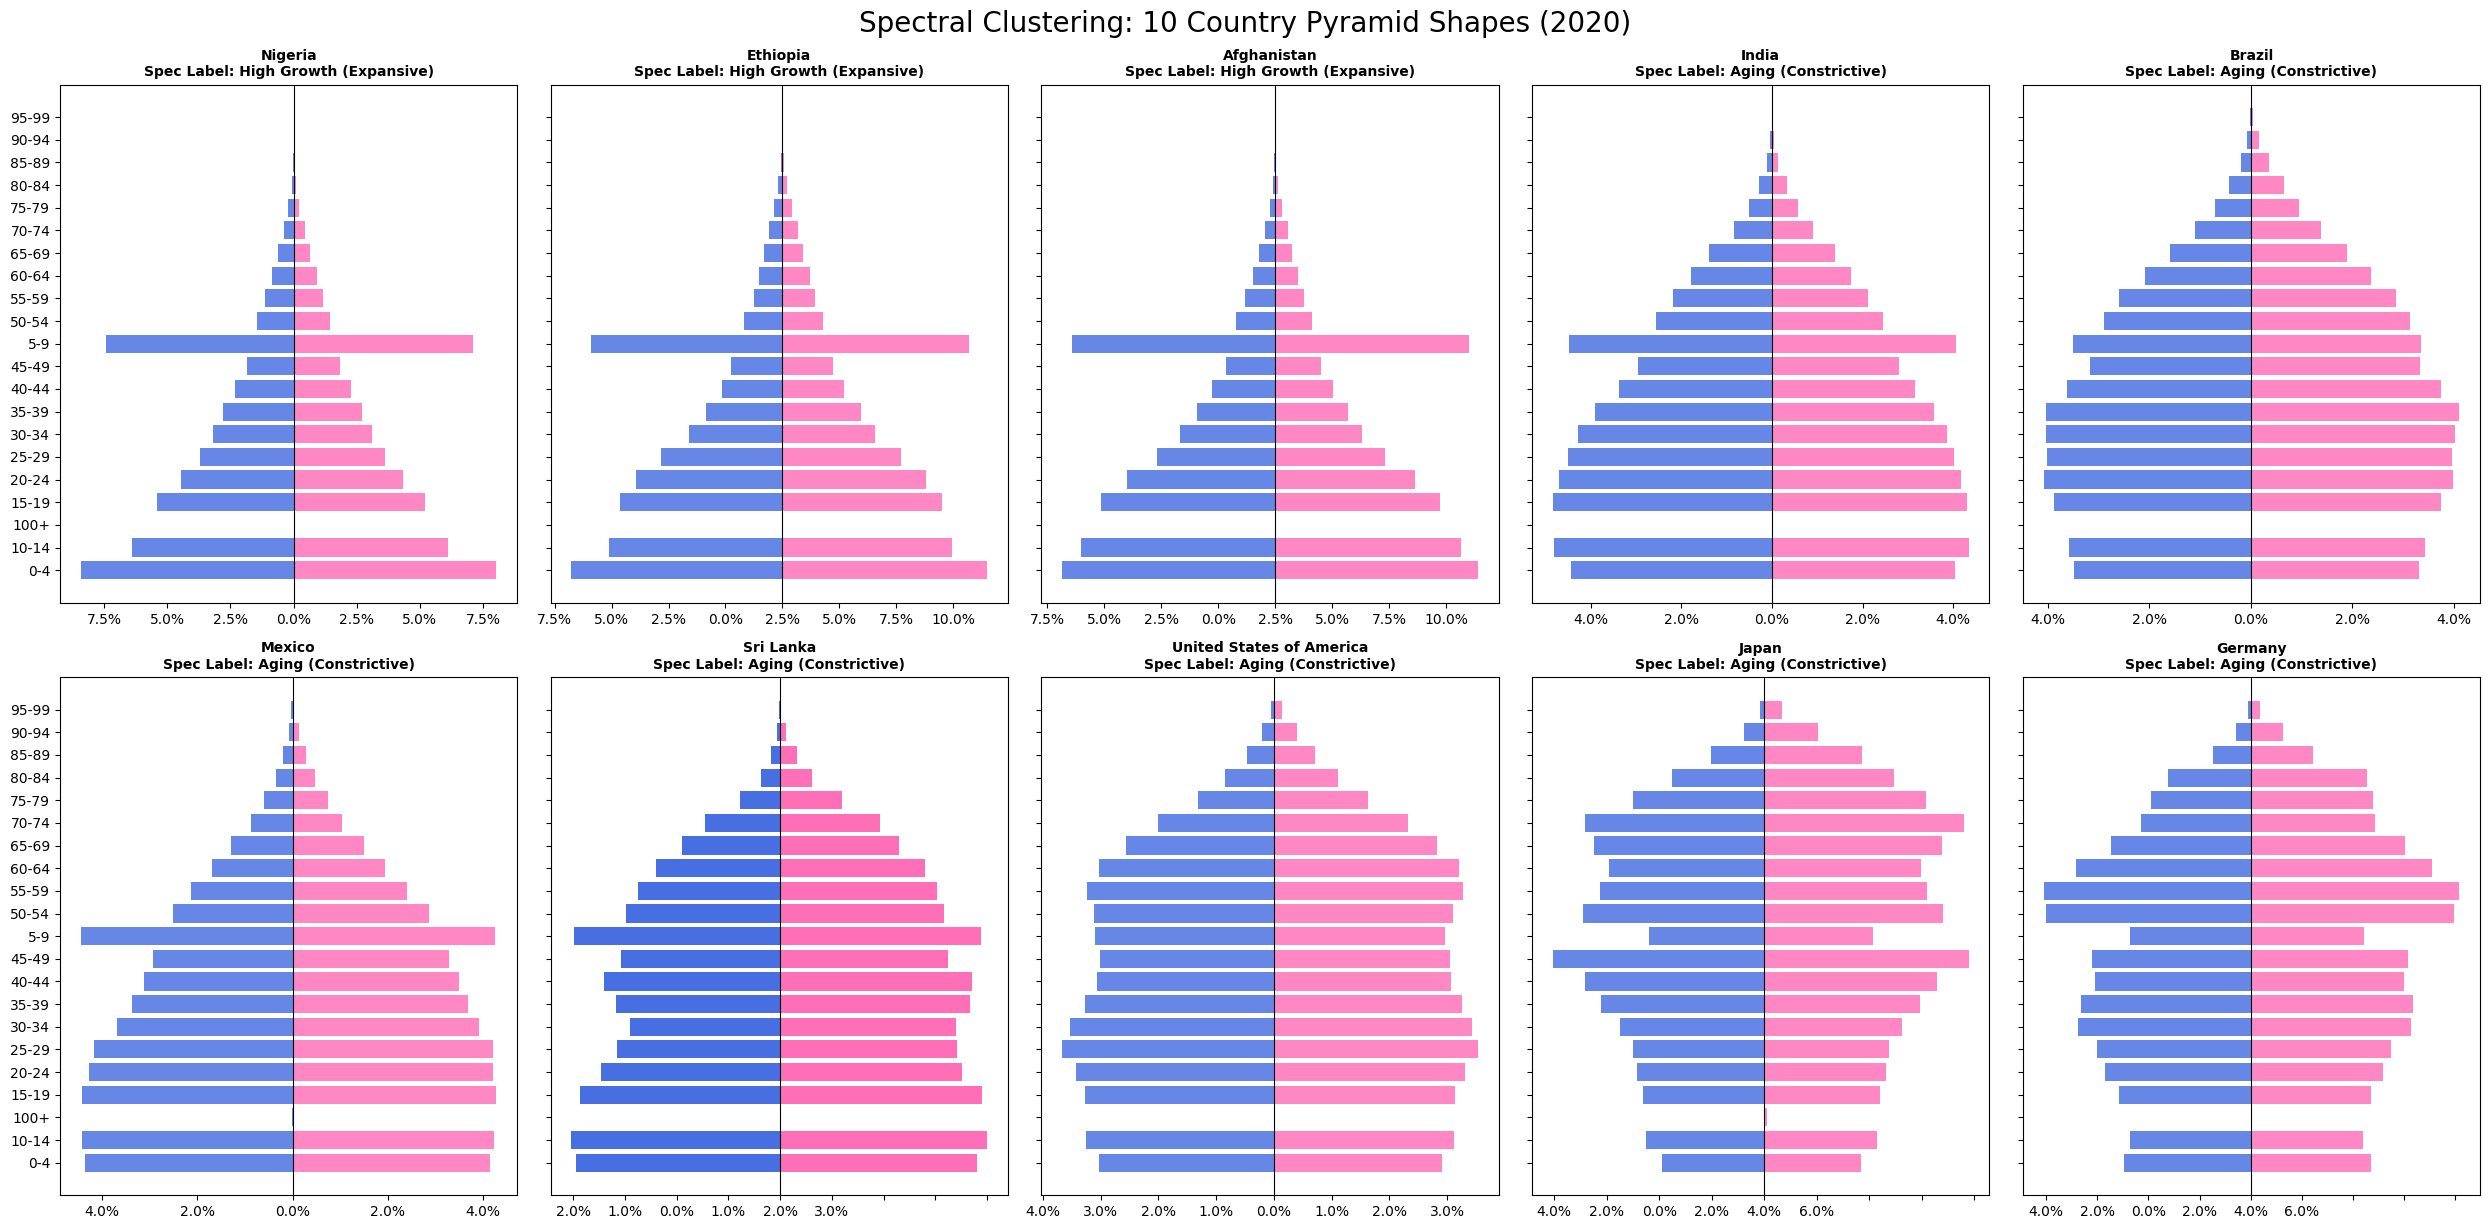

In [25]:
import matplotlib.pyplot as plt

# Select 10 diverse countries
countries_10 = ['Nigeria', 'Ethiopia', 'Afghanistan', 'India', 'Brazil',
                'Mexico', 'Sri Lanka', 'United States of America', 'Japan', 'Germany']

# Create the figure for Spectral
fig, axes = plt.subplots(2, 5, figsize=(25, 12), sharey=True)
axes = axes.flatten()

for i, country in enumerate(countries_10):
    ax = axes[i]
    # Filter 2020 data
    data = df[(df['Location'] == country) & (df['Time'] == 2020)].sort_values('AgeGrp')

    if data.empty: continue

    # Get the Spectral Label
    label = X.loc[country, 'Spectral_Label']

    # Calculate percentages
    total = data['PopTotal'].sum()
    m_pct = (data['PopMale'] / total) * 100
    f_pct = (data['PopFemale'] / total) * 100

    # Plot
    ax.barh(data['AgeGrp'], -m_pct, color='royalblue', alpha=0.8, label='Male')
    ax.barh(data['AgeGrp'], f_pct, color='hotpink', alpha=0.8, label='Female')
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(f"{country}\nSpec Label: {label}", fontsize=10, fontweight='bold')

    # Clean up X-axis
    ticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Spectral Clustering: 10 Country Pyramid Shapes (2020)", fontsize=20, y=1.02)
plt.show()

/tmp/ipython-input-3382545503.py:29: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3382545503.py:29: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3382545503.py:29: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3382545503.py:29: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3382545503.py:29: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3382545503.py:29: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

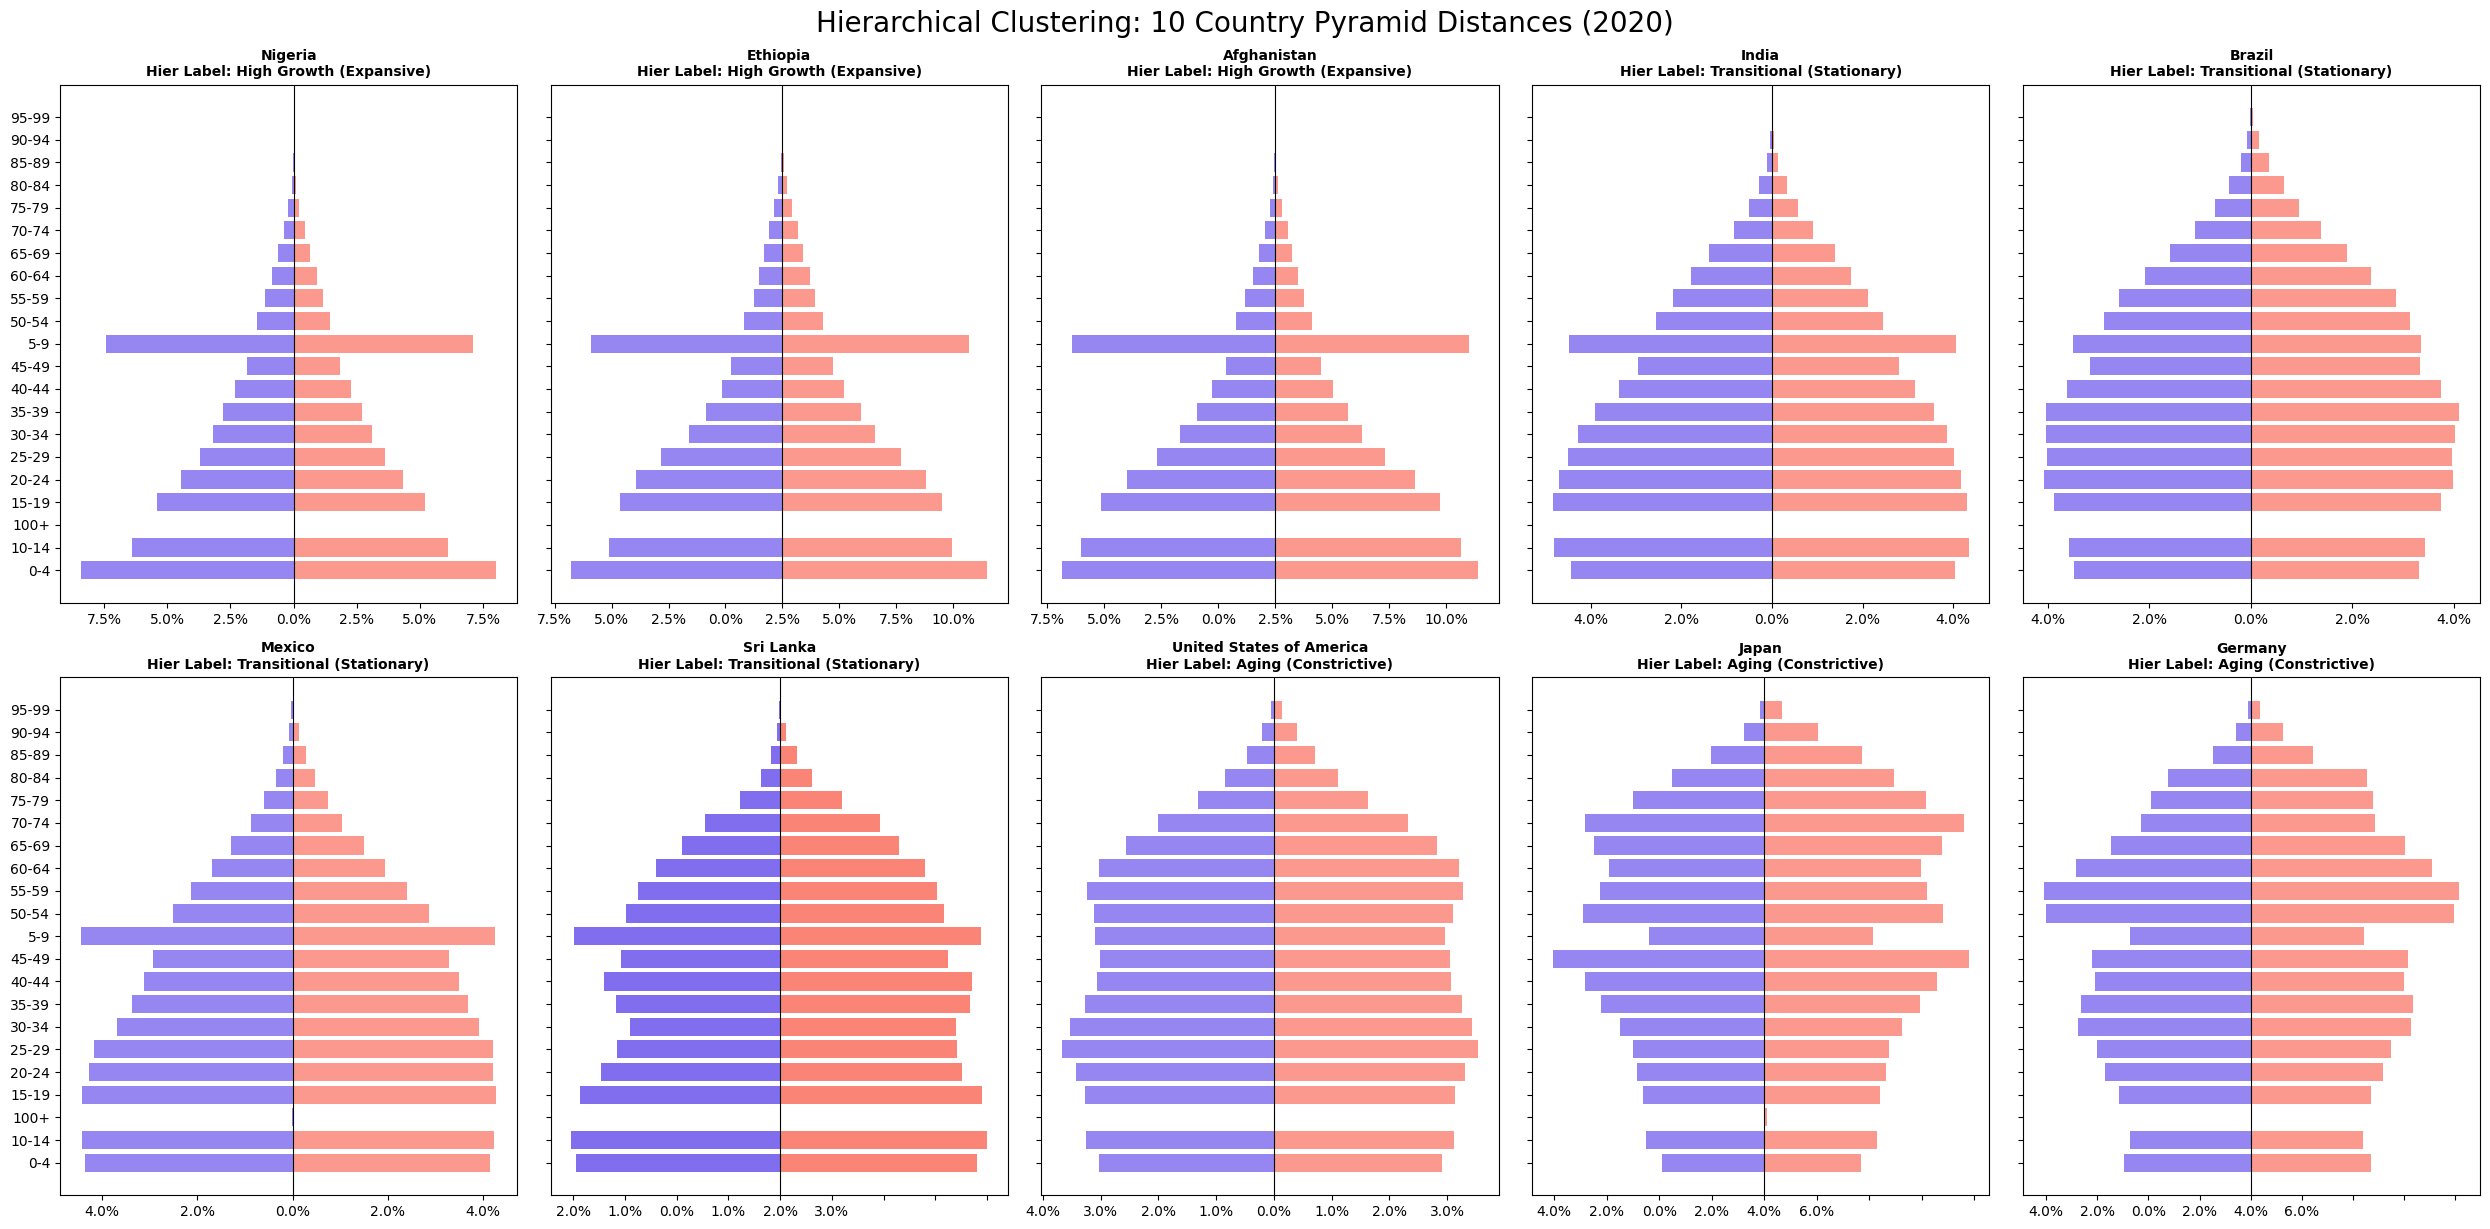

In [26]:
# Create the figure for Hierarchical
fig, axes = plt.subplots(2, 5, figsize=(25, 12), sharey=True)
axes = axes.flatten()

for i, country in enumerate(countries_10):
    ax = axes[i]
    # Filter 2020 data
    data = df[(df['Location'] == country) & (df['Time'] == 2020)].sort_values('AgeGrp')

    if data.empty: continue

    # Get the Hierarchical Label
    label = X.loc[country, 'Hierarchical_Label']

    # Calculate percentages
    total = data['PopTotal'].sum()
    m_pct = (data['PopMale'] / total) * 100
    f_pct = (data['PopFemale'] / total) * 100

    # Plot
    ax.barh(data['AgeGrp'], -m_pct, color='mediumslateblue', alpha=0.8)
    ax.barh(data['AgeGrp'], f_pct, color='salmon', alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(f"{country}\nHier Label: {label}", fontsize=10, fontweight='bold')

    # Clean up X-axis
    ticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Hierarchical Clustering: 10 Country Pyramid Distances (2020)", fontsize=20, y=1.02)
plt.show()

In [ ]:
import plotly.express as px

def get_cluster_labels(df, cluster_col):
    """
    Automatically assigns demographic labels by checking the
    proportion of young age groups (e.g., PopTotal_0-4).
    """
    # Find a column that represents a young age group to determine the 'Growth' level
    # We use a broad '0-4' or '5-9' filter
    young_cols = [col for col in X_pct.columns if '0-4' in col or '5-9' in col]

    # Calculate the mean 'youth' percentage for each cluster
    youth_means = X_pct.groupby(df[cluster_col])[young_cols].mean().mean(axis=1)

    # Sort clusters by youth percentage: High = High Growth, Low = Aging
    sorted_clusters = youth_means.sort_values(ascending=False).index

    mapping = {
        sorted_clusters[0]: "High Growth (Expansive)",
        sorted_clusters[1]: "Transitional (Stationary)",
        sorted_clusters[2]: "Aging (Constrictive)"
    }
    return mapping

# --- SPECTRAL MAPPING ---
spec_mapping = get_cluster_labels(X, 'Cluster')
X['Spectral_Label'] = X['Cluster'].map(spec_mapping)

# --- HIERARCHICAL MAPPING ---
hier_mapping = get_cluster_labels(X, 'HC_Cluster')
X['Hierarchical_Label'] = X['HC_Cluster'].map(hier_mapping)

# 2. Visualization: Spectral World Map
fig_spec = px.choropleth(
    X.reset_index(),
    locations="Location",
    locationmode="country names",
    color="Spectral_Label",
    title="Spectral Clustering: Demographic Stages 2020",
    color_discrete_map={
        "High Growth (Expansive)": "#EF553B",  # Red
        "Transitional (Stationary)": "#636EFA", # Blue
        "Aging (Constrictive)": "#00CC96"       # Green
    }
)
fig_spec.show()

# 3. Visualization: Hierarchical World Map
fig_hier = px.choropleth(
    X.reset_index(),
    locations="Location",
    locationmode="country names",
    color="Hierarchical_Label",
    title="Hierarchical Clustering: Demographic Stages 2020",
    color_discrete_map={
        "High Growth (Expansive)": "#EF553B",
        "Transitional (Stationary)": "#636EFA",
        "Aging (Constrictive)": "#00CC96"
    }
)
fig_hier.show()

In [ ]:
# Create the comparison table
comparison_df = X[['Cluster', 'Spectral_Label', 'HC_Cluster', 'Hierarchical_Label']].copy()
comparison_df.reset_index(inplace=True)

# Sort by Spectral Label to keep groups together
comparison_df = comparison_df.sort_values(by=['Spectral_Label', 'Location'])

# Display the first few rows of the table
print(comparison_df.head(20))

# Save the final table to CSV for your report
comparison_df.to_csv('country_clustering_comparison.csv', index=False)
print("\nSuccess: 'country_clustering_comparison.csv' has been created.")

Feature                          Location  Cluster        Spectral_Label  \
1                                 Albania        0  Aging (Constrictive)   
2                                 Algeria        0  Aging (Constrictive)   
4                     Antigua and Barbuda        0  Aging (Constrictive)   
5                               Argentina        0  Aging (Constrictive)   
6                                 Armenia        0  Aging (Constrictive)   
7                               Australia        0  Aging (Constrictive)   
8                                 Austria        0  Aging (Constrictive)   
9                              Azerbaijan        0  Aging (Constrictive)   
10                                Bahamas        0  Aging (Constrictive)   
12                             Bangladesh        0  Aging (Constrictive)   
13                               Barbados        0  Aging (Constrictive)   
14                                Belarus        0  Aging (Constrictive)   
15          

In [ ]:
# Find countries where the two methods disagree
mismatches = comparison_df[comparison_df['Spectral_Label'] != comparison_df['Hierarchical_Label']]
print(f"Number of countries with different classifications: {len(mismatches)}")
print(mismatches[['Location', 'Spectral_Label', 'Hierarchical_Label']])

Number of countries with different classifications: 77
Feature              Location           Spectral_Label  \
2                     Algeria     Aging (Constrictive)   
4         Antigua and Barbuda     Aging (Constrictive)   
5                   Argentina     Aging (Constrictive)   
9                  Azerbaijan     Aging (Constrictive)   
10                    Bahamas     Aging (Constrictive)   
..                        ...                      ...   
155              South Africa  High Growth (Expansive)   
163      Syrian Arab Republic  High Growth (Expansive)   
164                Tajikistan  High Growth (Expansive)   
172              Turkmenistan  High Growth (Expansive)   
180                Uzbekistan  High Growth (Expansive)   

Feature         Hierarchical_Label  
2        Transitional (Stationary)  
4        Transitional (Stationary)  
5        Transitional (Stationary)  
9        Transitional (Stationary)  
10       Transitional (Stationary)  
..                        

/tmp/ipython-input-2472259782.py:55: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2472259782.py:55: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2472259782.py:55: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2472259782.py:55: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2472259782.py:55: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2472259782.py:55: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

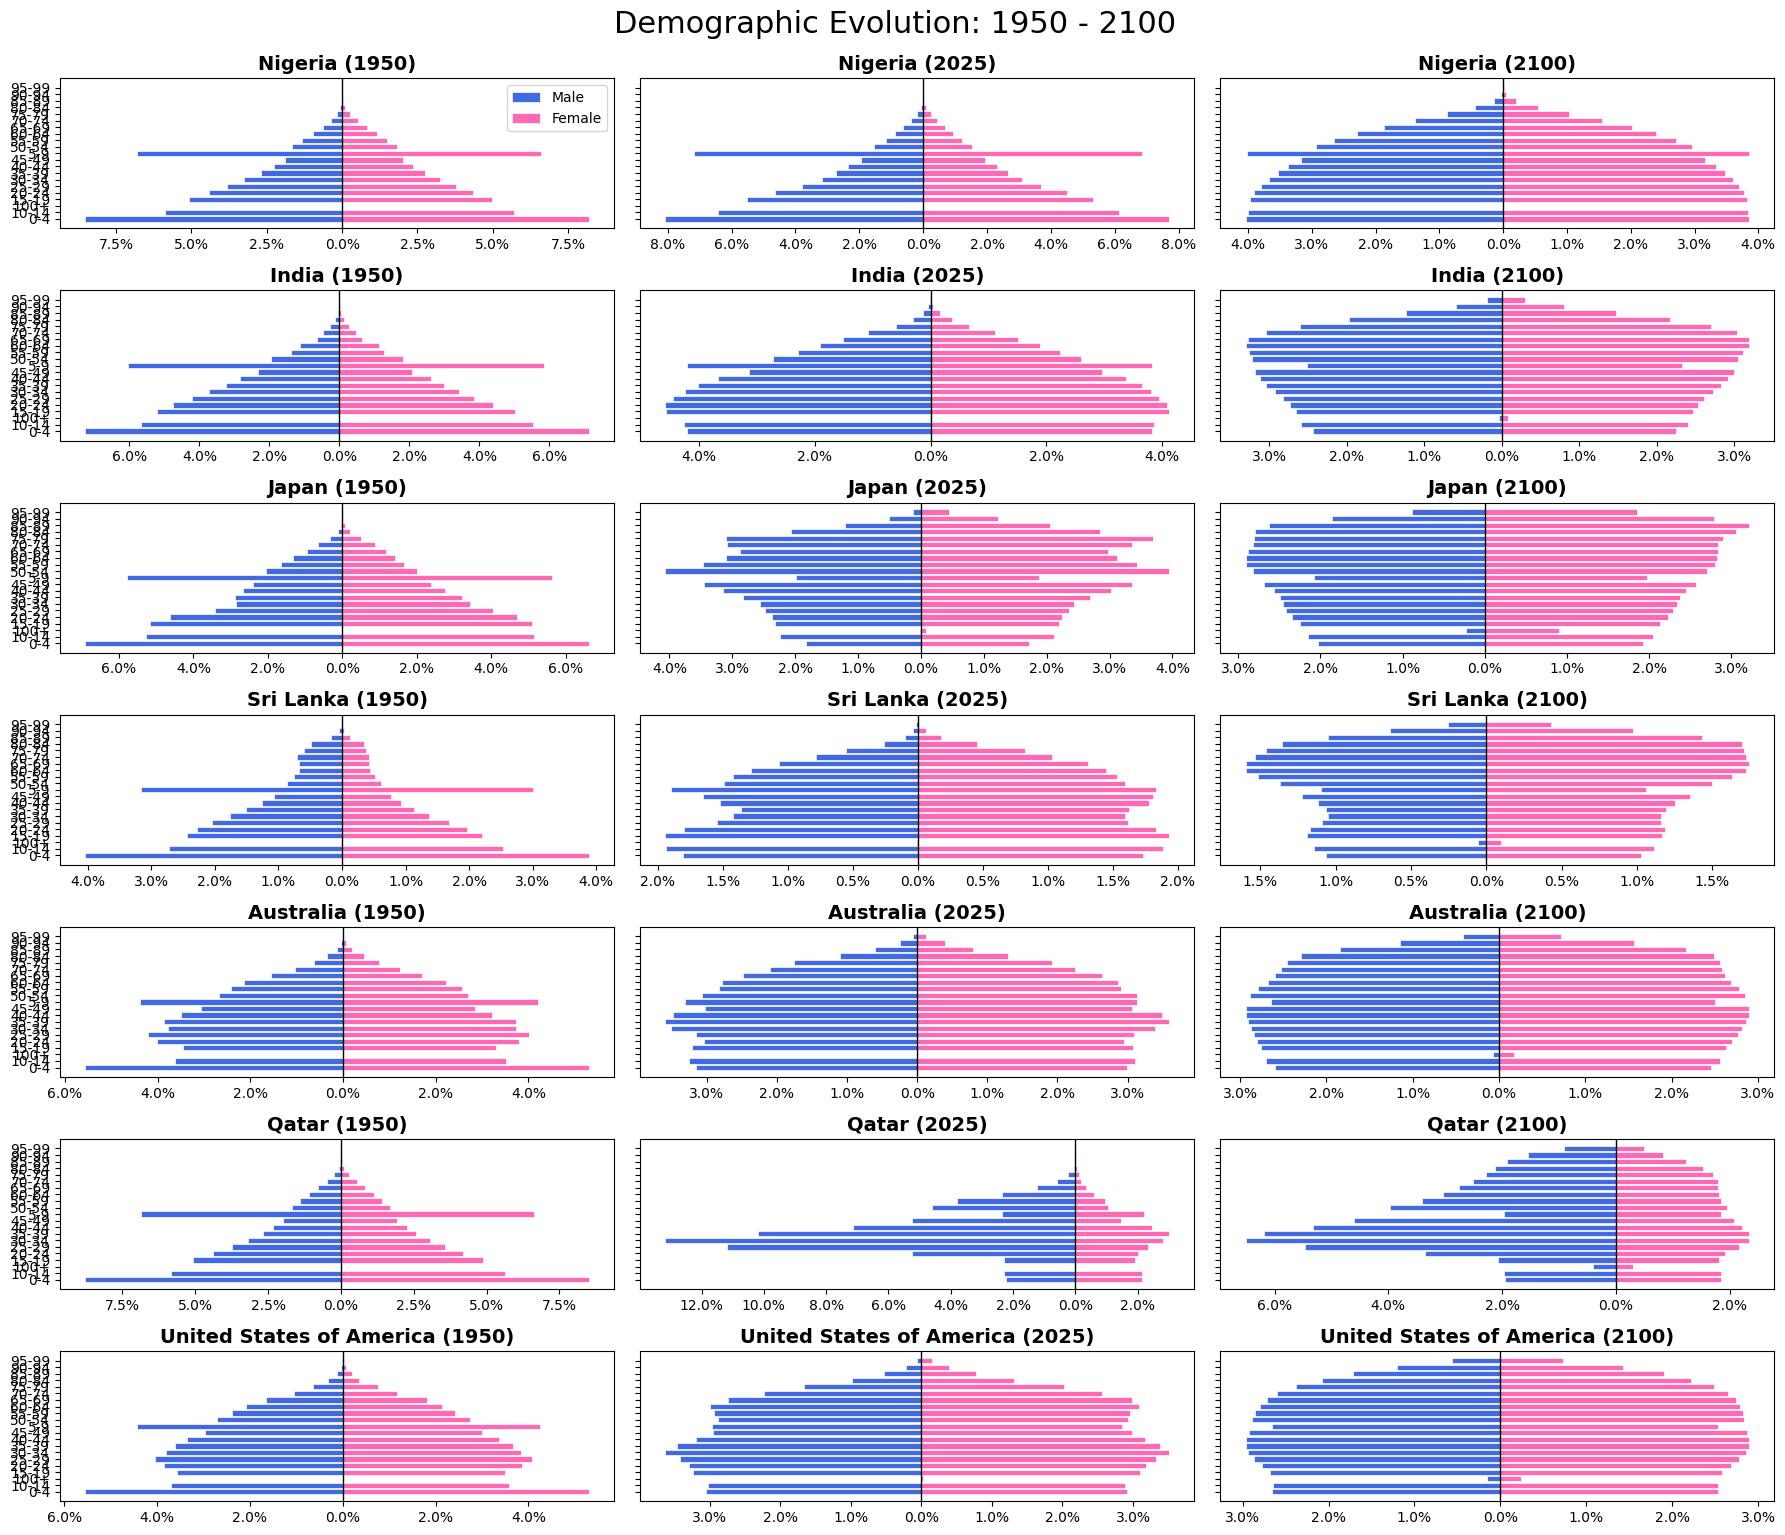

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('age_data_1.csv')

# 2. Setup Countries and Years to visualize
# You can change these to any countries in your dataset
target_countries = ['Nigeria', 'India', 'Japan', 'Sri Lanka', 'Australia', 'Qatar','United States of America']
target_years = [1950, 2025, 2100]

# 3. Create the Visualization Grid
fig, axes = plt.subplots(len(target_countries), len(target_years),
                         figsize=(18, 15), sharey=True)

for i, country in enumerate(target_countries):
    for j, year in enumerate(target_years):
        ax = axes[i, j]

        # Filter data for specific country and year
        data = df[(df['Location'] == country) & (df['Time'] == year)]

        # In case the year doesn't exist in your dataset
        if data.empty:
            ax.text(0.5, 0.5, f"No Data for {year}", ha='center')
            continue

        # Ensure age groups are sorted (0-4 at bottom, 100+ at top)
        # You may need to manually sort 'AgeGrp' if it's not alphabetical
        data = data.sort_values('AgeGrp', ascending=True)

        ages = data['AgeGrp']
        male_pop = data['PopMale']
        female_pop = data['PopFemale']

        # Calculate percentage to keep pyramids comparable across years
        total = male_pop.sum() + female_pop.sum()
        m_pct = (male_pop / total) * 100
        f_pct = (female_pop / total) * 100

        # Plotting Males (Negative values to go Left)
        ax.barh(ages, -m_pct, color='royalblue', label='Male', edgecolor='white', linewidth=0.5)

        # Plotting Females (Positive values to go Right)
        ax.barh(ages, f_pct, color='hotpink', label='Female', edgecolor='white', linewidth=0.5)

        # Formatting
        ax.set_title(f"{country} ({year})", fontsize=14, fontweight='bold')
        ax.axvline(0, color='black', linewidth=1) # Center line

        # Adjust x-axis labels to show absolute values (removing negatives)
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

        if i == 0 and j == 0:
            ax.legend()

plt.tight_layout()
plt.suptitle("Demographic Evolution: 1950 - 2100", fontsize=22, y=1.02)
plt.show()

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp

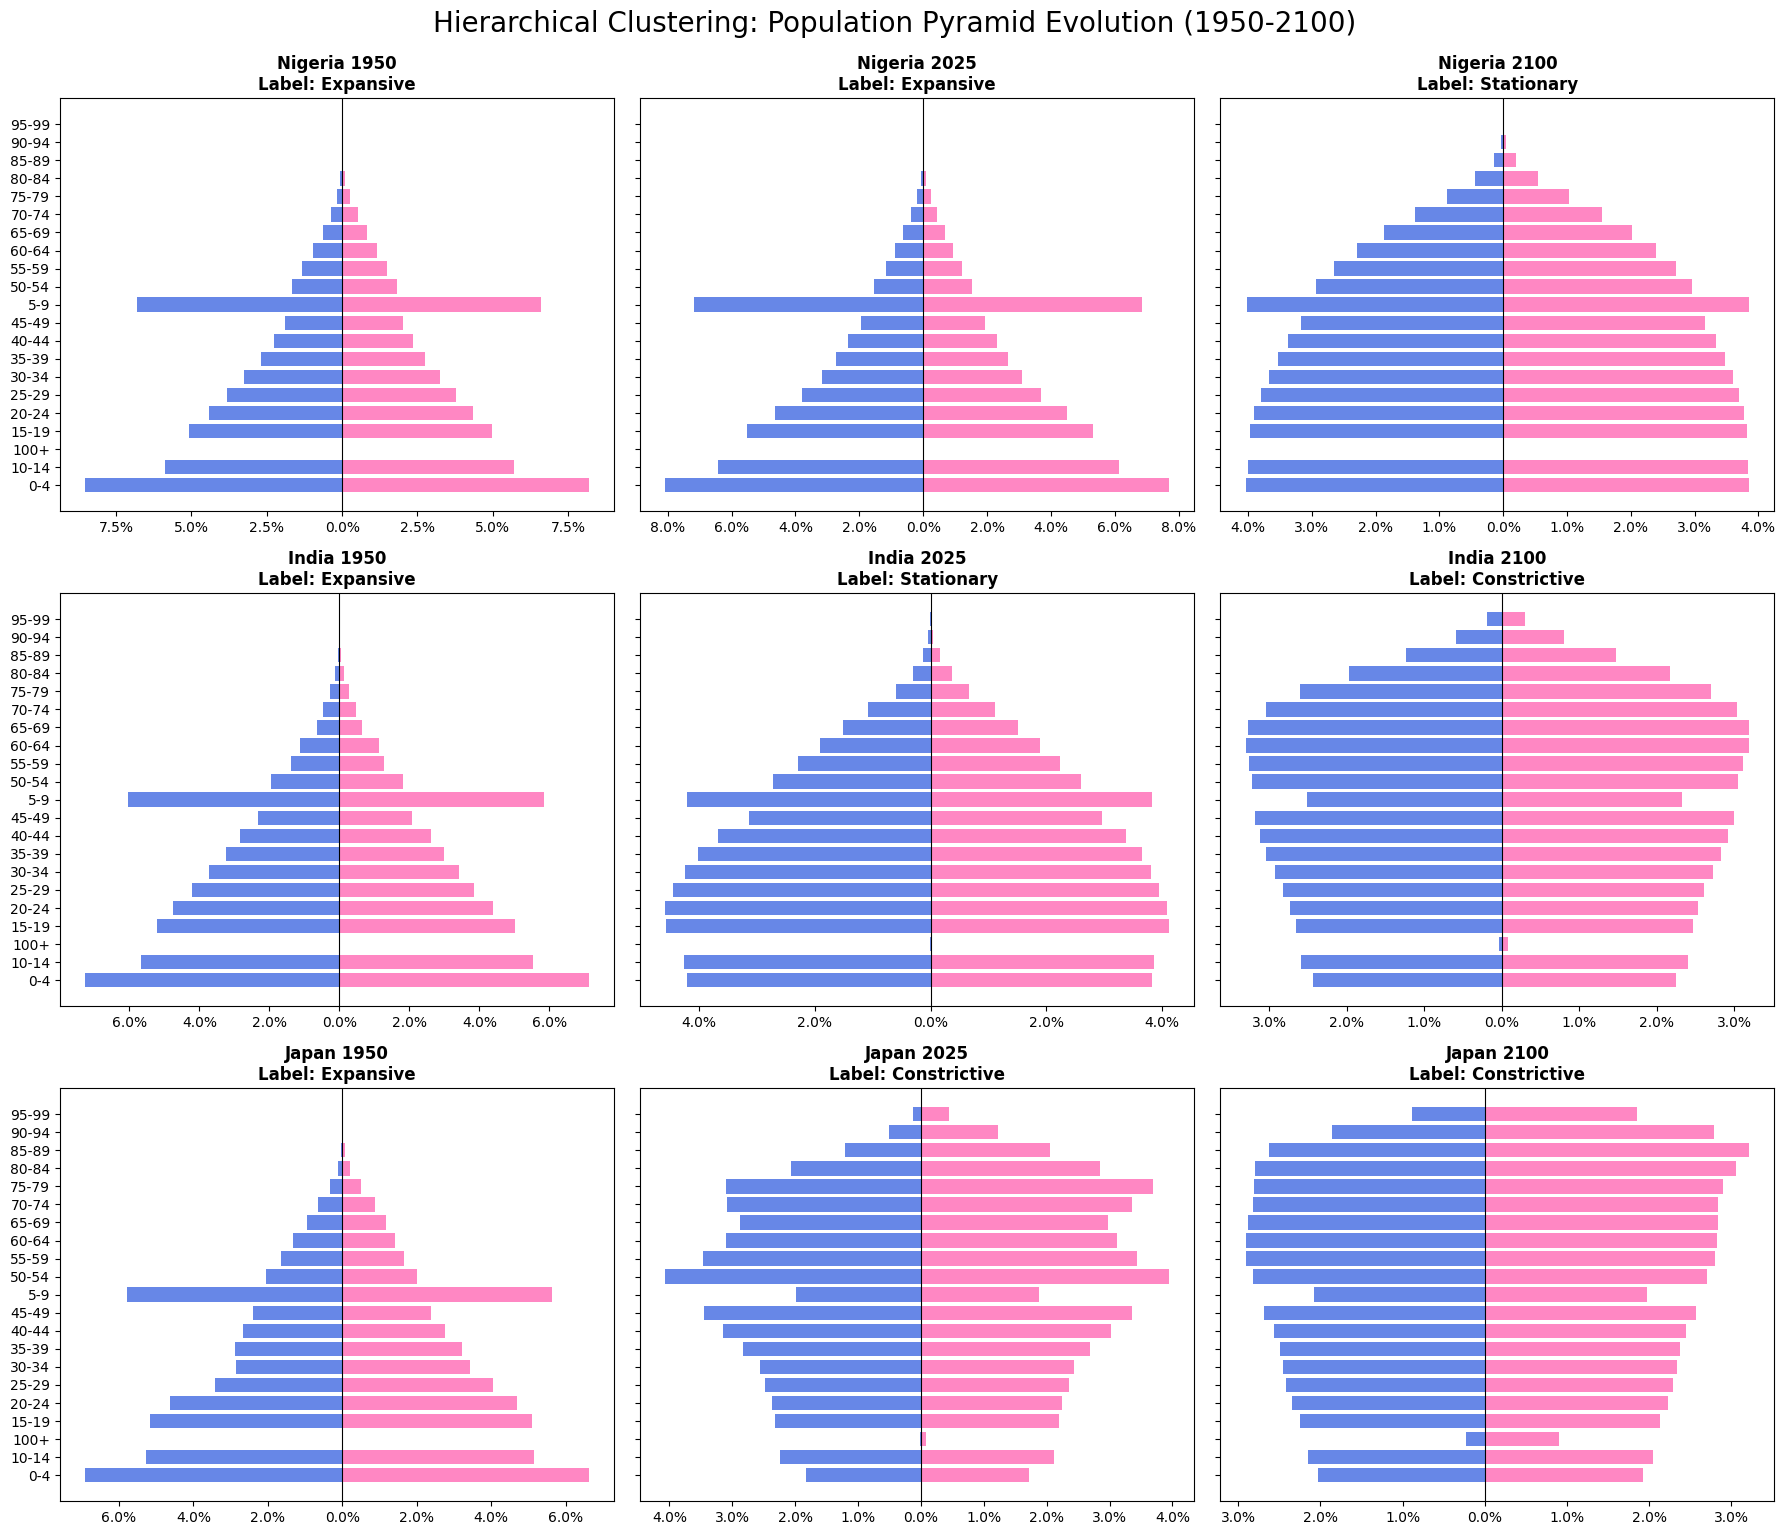

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Prepare Data for Hierarchical Labels (1950-2100)
# This ensures every country-year has a cluster assigned
X_pivot = df.pivot_table(index=['Location', 'Time'], columns='AgeGrp', values='PopTotal').fillna(0)
X_pct_global = X_pivot.div(X_pivot.sum(axis=1), axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct_global)
X_pca_global = PCA(n_components=0.95).fit_transform(X_scaled)

# Fit Hierarchical Model
hc_global = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
X_pivot['HC_Cluster'] = hc_global.fit_predict(X_pca_global)

# Determine Labels based on youth percentage (as done before)
# We find the cluster with highest 0-4 age group ratio
youth_col = X_pct_global.columns[0]
youth_order = X_pct_global.groupby(X_pivot['HC_Cluster'])[youth_col].mean().sort_values(ascending=False).index
hc_label_map = {youth_order[0]: "Expansive", youth_order[1]: "Stationary", youth_order[2]: "Constrictive"}

# 2. Plotting the Pyramids with HC Labels
target_countries = ['Nigeria', 'India', 'Japan'] # Example set
target_years = [1950, 2025, 2100]

fig, axes = plt.subplots(len(target_countries), len(target_years), figsize=(18, 15), sharey=True)

for i, country in enumerate(target_countries):
    for j, year in enumerate(target_years):
        ax = axes[i, j]

        # Get data and HC label
        country_data = df[(df['Location'] == country) & (df['Time'] == year)].sort_values('AgeGrp')
        if country_data.empty: continue

        cluster_id = X_pivot.loc[(country, year), 'HC_Cluster']
        label = hc_label_map[cluster_id]

        # Percentages for scale
        total = country_data['PopTotal'].sum()
        m_pct = (country_data['PopMale'] / total) * 100
        f_pct = (country_data['PopFemale'] / total) * 100
        ages = country_data['AgeGrp']

        # Plot
        ax.barh(ages, -m_pct, color='royalblue', alpha=0.8, label='Male')
        ax.barh(ages, f_pct, color='hotpink', alpha=0.8, label='Female')

        # Styling
        ax.set_title(f"{country} {year}\nLabel: {label}", fontsize=12, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.8)

        # Formatting X-axis to show positive percentage values
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Hierarchical Clustering: Population Pyramid Evolution (1950-2100)", fontsize=20, y=1.02)
plt.show()

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-415916169.py:60: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp

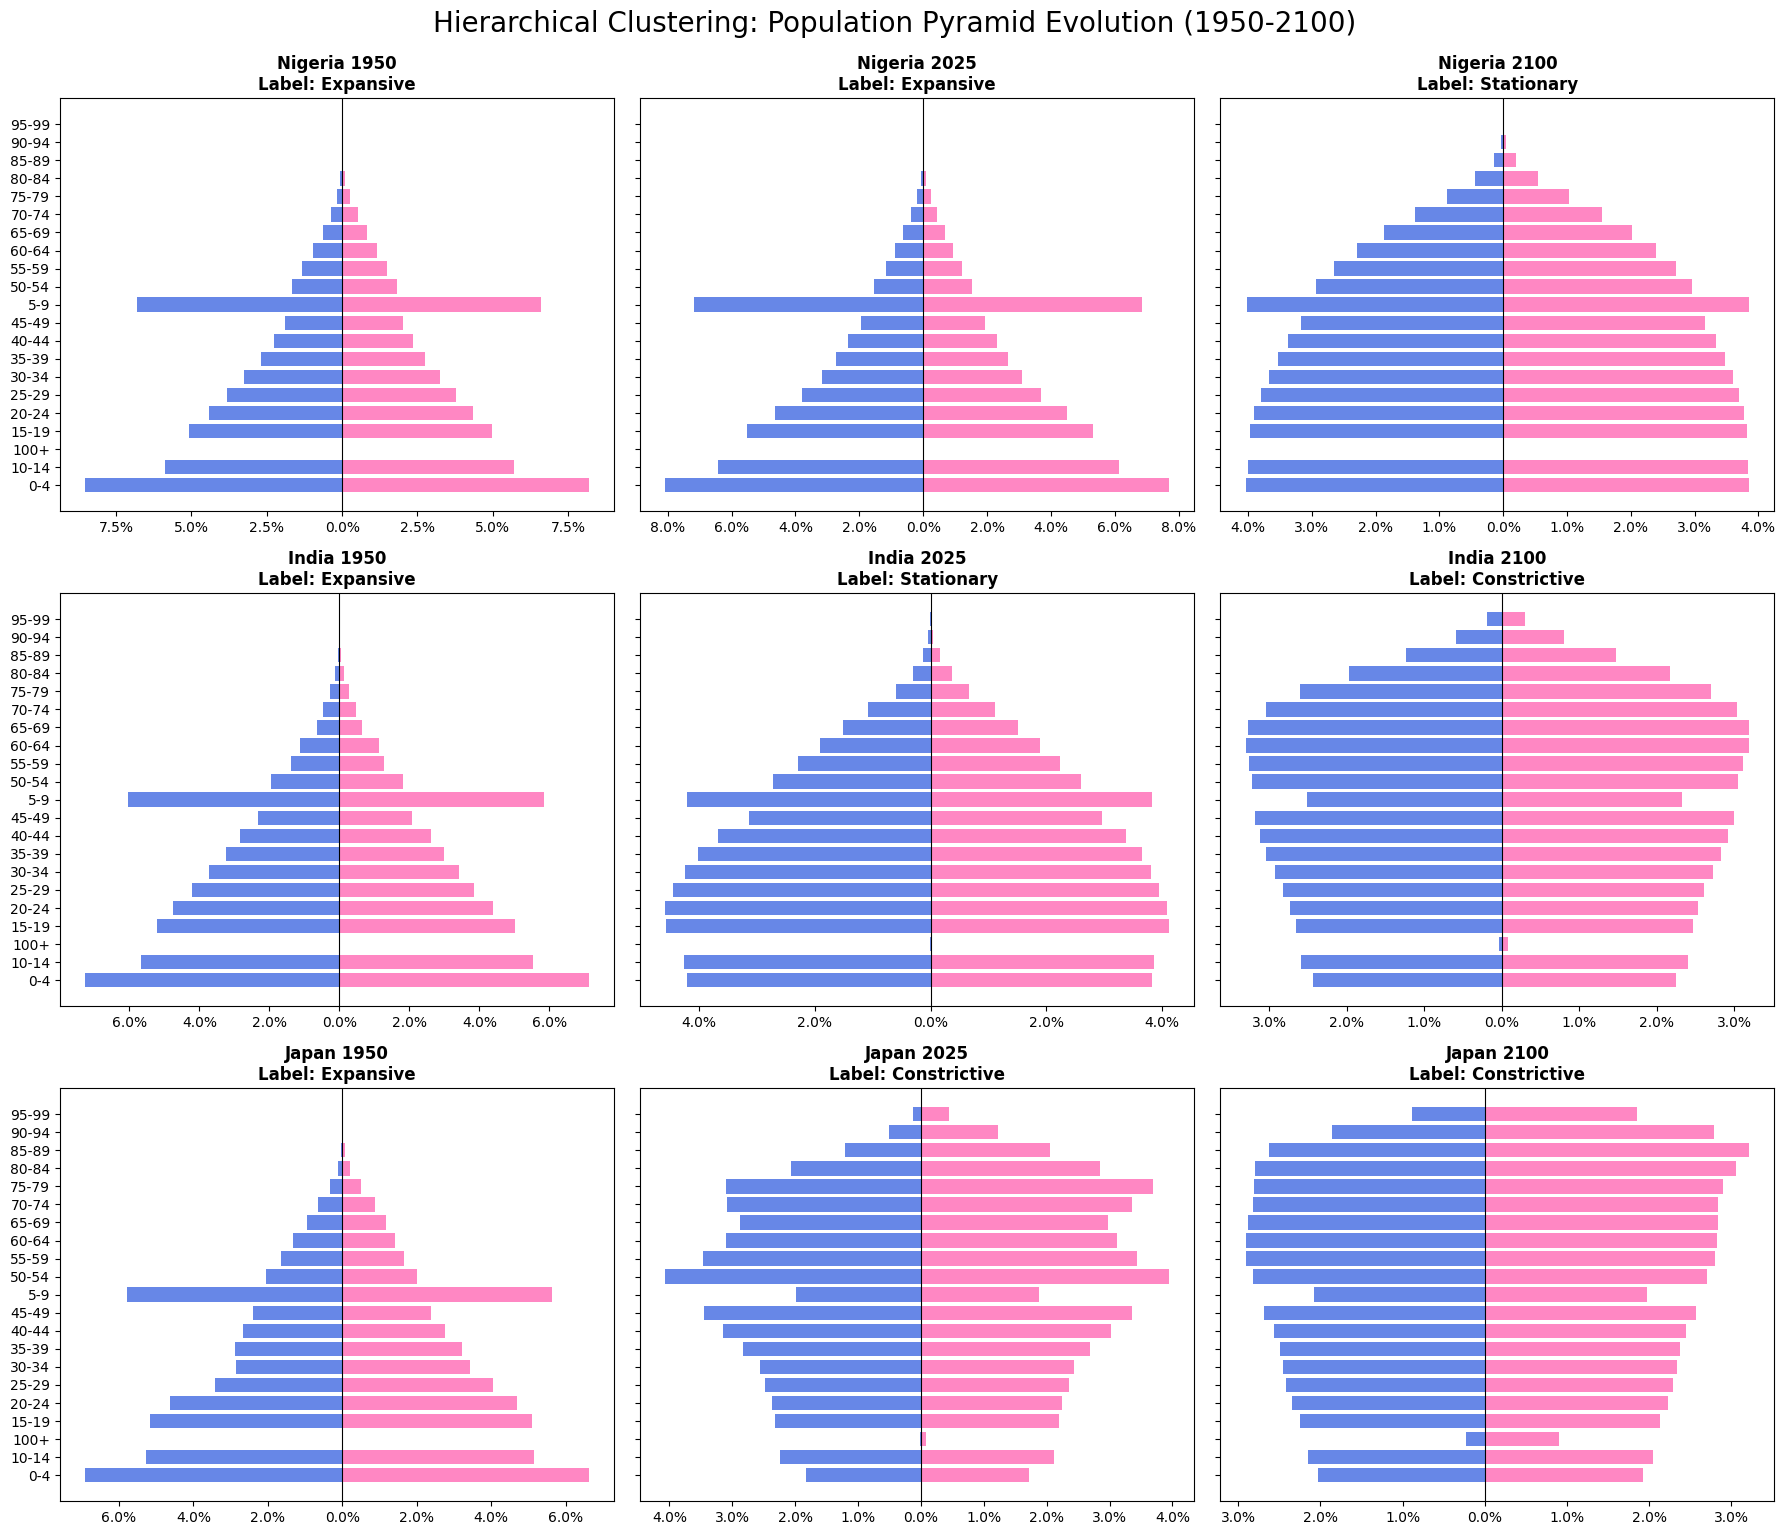

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Prepare Data for Hierarchical Labels (1950-2100)
# This ensures every country-year has a cluster assigned
X_pivot = df.pivot_table(index=['Location', 'Time'], columns='AgeGrp', values='PopTotal').fillna(0)
X_pct_global = X_pivot.div(X_pivot.sum(axis=1), axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct_global)
X_pca_global = PCA(n_components=0.95).fit_transform(X_scaled)

# Fit Hierarchical Model
hc_global = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
X_pivot['HC_Cluster'] = hc_global.fit_predict(X_pca_global)

# Determine Labels based on youth percentage (as done before)
# We find the cluster with highest 0-4 age group ratio
youth_col = X_pct_global.columns[0]
youth_order = X_pct_global.groupby(X_pivot['HC_Cluster'])[youth_col].mean().sort_values(ascending=False).index
hc_label_map = {youth_order[0]: "Expansive", youth_order[1]: "Stationary", youth_order[2]: "Constrictive"}

# 2. Plotting the Pyramids with HC Labels
target_countries = ['Nigeria', 'India', 'Japan'] # Example set
target_years = [1950, 2025, 2100]

fig, axes = plt.subplots(len(target_countries), len(target_years), figsize=(18, 15), sharey=True)

for i, country in enumerate(target_countries):
    for j, year in enumerate(target_years):
        ax = axes[i, j]

        # Get data and HC label
        country_data = df[(df['Location'] == country) & (df['Time'] == year)].sort_values('AgeGrp')
        if country_data.empty: continue

        cluster_id = X_pivot.loc[(country, year), 'HC_Cluster']
        label = hc_label_map[cluster_id]

        # Percentages for scale
        total = country_data['PopTotal'].sum()
        m_pct = (country_data['PopMale'] / total) * 100
        f_pct = (country_data['PopFemale'] / total) * 100
        ages = country_data['AgeGrp']

        # Plot
        ax.barh(ages, -m_pct, color='royalblue', alpha=0.8, label='Male')
        ax.barh(ages, f_pct, color='hotpink', alpha=0.8, label='Female')

        # Styling
        ax.set_title(f"{country} {year}\nLabel: {label}", fontsize=12, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.8)

        # Formatting X-axis to show positive percentage values
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Hierarchical Clustering: Population Pyramid Evolution (1950-2100)", fontsize=20, y=1.02)
plt.show()